# 09 - Variational Autoencoder on Full AU Mic Spectra

In this notebook, I adapt Isidro Gómez-Vargas's VAE architecture to the 1D high-resolution spectra of AU Mic.  
The goal is to compress each spectrum into a low-dimensional latent representation while preserving activity-related variability.

I do the following:
- Preprocess AU Mic spectra, stacking selected spectral orders
- Train a flexible 1D CNN VAE
- Visualize the latent space using PCA and t-SNE
- Save the encoder and decoder models for future analysis

### **Setting up the GPU:**

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))
print("Using GPU:", tf.test.is_gpu_available())

2025-05-19 00:21:56.909591: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 00:21:56.944660: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-19 00:21:56.944700: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-19 00:21:56.945630: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-19 00:21:56.951674: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
Using GPU: True


2025-05-19 00:21:58.447324: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-19 00:21:58.476744: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-19 00:21:58.481903: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### **Importimg relevant Libraries:**

In [2]:
import sys
sys.path.append("../src")
from spectrumnet import SpecVaeCnn1D
from spectrumnet.vae_model import save_all_models

[2025-05-19 00:21:58] [INFO] VAE model file imported.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from astropy.io import fits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from astropy.timeseries import LombScargle

In [6]:
import umap

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading the Files:**

In [7]:
with open("../../aumicAE/data/carvis_visA/vis_a_files.txt", "r") as f:
    vis_a_files = ["../../aumicAE/" + line.strip().lstrip("../") for line in f if line.strip()]

**Load metadata (sorted and cleaned):**

In [8]:
meta = pd.read_csv("../outputs/aligned_metadata/aligned_metadata_snr_filtered.csv")
meta = meta.sort_values("BJD").reset_index(drop=True)

**For the Outputs:**

In [9]:
import os
os.makedirs("outputs/plots", exist_ok=True)

#### **Preprocess AU Mic spectra**

I include the orders 10 to 38, i.e., I **skip the first 10 and the last 17 orders**.

In [10]:
#valid_orders = list(range(10, 39)) 

Using less orders:

In [11]:
valid_orders = [25, 46, 47]

**Stack selected orders:**

In this stacking, I include the relevent preprocessing, i.e. the continuum normalization with clipping for stability - this is the standard way.

In [12]:
def stack_orders(file_path, orders=valid_orders):
    with fits.open(file_path) as hdul:
        flux = hdul["SPEC"].data
        cont = hdul["CONT"].data
        spec = flux / np.clip(cont, 1e-3, np.inf)
        spec = np.nan_to_num(spec, nan=0.0, posinf=0.0, neginf=0.0)
        return np.hstack([spec[o] for o in orders])

X = np.array([stack_orders(f) for f in vis_a_files])
print("Stacked shape:", X.shape)

Stacked shape: (95, 12288)


**Normalize and split:**

Make sure meta is aligned 1:1 with X before splitting:

In [13]:
assert len(meta) == len(X)

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_train, x_test, meta_train, meta_test = train_test_split(X_scaled, meta, test_size=0.2, random_state=0, shuffle=True)
print("Train shape:", x_train.shape)

Train shape: (76, 12288)


## Define and Train the Variational Autoencoder

I use a flexible CNN-based VAE architecture (from `SpecVaeCnn1D`) with configurable convolution and dense layers.

---

`tanh` stands for **hyperbolic tangent**, and it’s a smooth, non-linear activation function used in neural networks.

The mathematical form is:

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

| Feature           | Description                                                                        |
| ----------------- | ---------------------------------------------------------------------------------- |
| Output range      | **Between -1 and 1**                                                               |
| Centered          | Yes — outputs are centered around 0                                                |
| Shape             | S-shaped (sigmoid-like), symmetric                                                 |
| Use in your model | Adds non-linearity to the encoder and decoder, helping them learn complex mappings |
| Gradient behavior | Can **saturate** for large inputs (i.e., gradient becomes near-zero)               |

```
    |       ~~~~~~~
  1 |     ~
    |   ~
    | ~
  0 |------------------
    | ~
 -1 |   ~
    |     ~~~~~~~
```

* It’s **smooth and bounded**, which works well for stabilizing training, especially with spectral inputs that are normalized.
* It’s often preferred over ReLU in **autoencoders** when the goal is to reconstruct signals that are both positive and negative (e.g., normalized residuals).

---

| Callback               | What it does                                                              |
| ---------------------- | ------------------------------------------------------------------------- |
| `EarlyStopping`        | Stops training if validation loss stops improving (for `patience` epochs) |
| `restore_best_weights` | Ensures model returns to best weights (not final ones) after stopping     |
| `ReduceLROnPlateau`    | Lowers learning rate if val loss stagnates (helps escape bad plateaus)    |

---

**Building the VAE:**

Define hyperparamters:

In [15]:
latent_dim = 5
deep = [200, 100] # Sizes of the dense layers in the encoder and decoder
actfn = "tanh" # Activation function used in dense and conv layers
dropout = 0.2
learning_rate = 1e-3
epochs = 50
batch_size = 16
patience = 20

Define the model:

In [16]:
vae_model = SpecVaeCnn1D(
    n_inputs=X.shape[1],
    dense_layers=deep,
    dropout=dropout,
    actfn=actfn,
    latent_dim=latent_dim
)

[2025-05-19 00:22:03] [INFO] TensorFlow Version: 2.15.0
[2025-05-19 00:22:03] [INFO] Num GPUs Available: 1


In [17]:
print(x_train.shape)

(76, 12288)


**Simpler Architecture:**

In [18]:
vae_model = SpecVaeCnn1D(
    n_inputs=12288,
    latent_dim=8,  # Reduce latent space
    dropout=0.1,  # Lighter dropout
    actfn='relu',  # Faster and simpler than 'tanh'
    mcdropout=True,
    conv_layers=[(32, 3), (64, 3)],  # Shallower Conv stack
    dense_layers=[128, 64]  # Fewer neurons
)

[2025-05-19 00:22:03] [INFO] TensorFlow Version: 2.15.0
[2025-05-19 00:22:03] [INFO] Num GPUs Available: 1


Build the architecture:

In [19]:
vae, encoder, decoder = vae_model.model_tf() 

[2025-05-19 00:22:03] [INFO] Building flexible 1D CNN VAE...
2025-05-19 00:22:03.193157: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-19 00:22:03.194441: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-19 00:22:03.195330: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 12288)]              0         []                            
                                                                                                  
 reshape (Reshape)           (None, 12288, 1)             0         ['input_1[0][0]']             
                                                                                                  
 conv1d (Conv1D)             (None, 12288, 32)            128       ['reshape[0][0]']             
                                                                                                  
 average_pooling1d (Average  (None, 2457, 32)             0         ['conv1d[0][0]']              
 Pooling1D)                                                                                 

[2025-05-19 00:22:03] [INFO] None
[2025-05-19 00:22:03] [INFO] MCDropout initialized with rate=0.1, is_disabled=False
[2025-05-19 00:22:03] [INFO] MCDropout initialized with rate=0.1, is_disabled=False
[2025-05-19 00:22:03] [INFO] MCDropout initialized with rate=0.1, is_disabled=False
[2025-05-19 00:22:03] [INFO] MCDropout initialized with rate=0.1, is_disabled=False
[2025-05-19 00:22:03] [INFO] MCDropout initialized with rate=0.1, is_disabled=False


Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 8)]               0         
                                                                 
 dense_4 (Dense)             (None, 64)                576       
                                                                 
 mc_dropout_4 (MCDropout)    (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 128)               8320      
                                                                 
 mc_dropout_5 (MCDropout)    (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 31424)             4053696   
                                                                 
 reshape_1 (Reshape)         (None, 491, 64)           0   

[2025-05-19 00:22:03] [INFO] None


Compile:

In [20]:
vae_model.vae.compile(optimizer=Adam(learning_rate), loss='mse')

Include callbacks:

In [21]:
callbacks = [
    EarlyStopping(patience=patience, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.2, patience=patience // 2, monitor='val_loss')
]

**Training the VAE:**

In [22]:
history = vae_model.vae.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks
)

Epoch 1/50


2025-05-13 02:53:26.961118: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-05-13 02:53:28.164829: I external/local_xla/xla/service/service.cc:168] XLA service 0x7bc4fc21e7a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-13 02:53:28.164843: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-05-13 02:53:28.168763: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747097608.220022   29285 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 [==============================] - 65s 599ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 2/50
5/5 [==============================] - 0s 41ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 3/50
5/5 [==============================] - 0s 39ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 4/50
5/5 [==============================] - 0s 44ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 5/50
5/5 [==============================] - 0s 41ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 6/50
5/5 [==============================] - 0s 42ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 7/50
5/5 [==============================] - 0s 41ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 8/50
5/5 [==============================] - 0s 41ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 9/50
5/5 [==============================] - 0s 42ms/step - loss: nan - val_loss: nan - lr: 0.0010
Epoch 10/50
5/5 [==============================] - 0s 39ms/step - loss: n

Total time to run: 111 minutes, 24.9 seconds

**Saving the models:**


Install cuda with pip


use screen so it does not stop. 

screen -S name


JAX

ask chatgtp how to port your code to cuda


ask chat gpt what to do

In [ ]:
save_all_models(vae_model.vae, vae_model.encoder, vae_model.decoder, "outputs/models/vae_full/vae")

In [ ]:
vae.save("outputs/models/vae_full/vae_fullmodel.keras")
encoder.save("outputs/models/vae_full/vae_encoder.keras")
decoder.save("outputs/models/vae_full/vae_decoder.keras")

**Plotting the training loss:**

In [ ]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("VAE Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
plt.savefig("outputs/plots/vae_full/initial/vae_loss_curve.png", dpi=150)

**Visualizing the latent space:**

Get latent means:

In [25]:
z_mean, _, _ = vae_model.encoder.predict(x_test)

1/1 [==============================] - 0s 247ms/step


PCA projection:

In [ ]:
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(z_mean)

plt.figure(figsize=(8, 5))
plt.scatter(latent_pca[:, 0], latent_pca[:, 1], c=meta["BJD"].values[-len(z_mean):], cmap="viridis")
plt.colorbar(label="BJD")
plt.title("Latent Space (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

t-SNE projection:

In [ ]:
tsne = TSNE(n_components=2, perplexity=min(30, len(z_mean) // 2), random_state=42)
latent_tsne = tsne.fit_transform(z_mean)

plt.figure(figsize=(8, 5))
plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=meta["BJD"].values[-len(z_mean):], cmap="viridis")
plt.colorbar(label="BJD")
plt.title("Latent Space (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()

### Lomb-Scargle Periodograms 

Extract BJD and latent dims:

In [28]:
time = meta_test["BJD"].values
z_mean, _, _ = vae_model.encoder.predict(x_test)
z_mean = np.array(z_mean)

1/1 [==============================] - 0s 17ms/step


Setup frequency grid (adjust range as needed):

In [29]:
rotation_period = 4.8367  # AU Mic rotation period
rotation_freq = 1 / rotation_period
frequencies = np.linspace(1/20, 1, 5000)  # From 0.05 to 2 cycles/day

Plot periodograms for each latent dim:

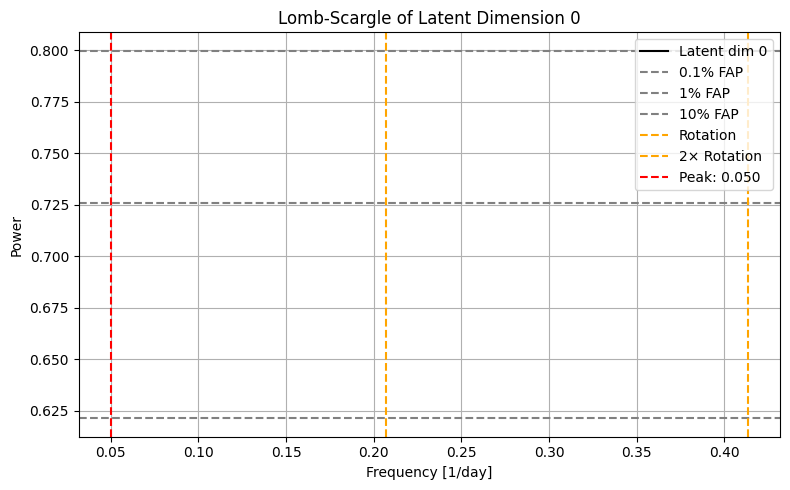

Latent dim 0 — Best period: 20.000 days


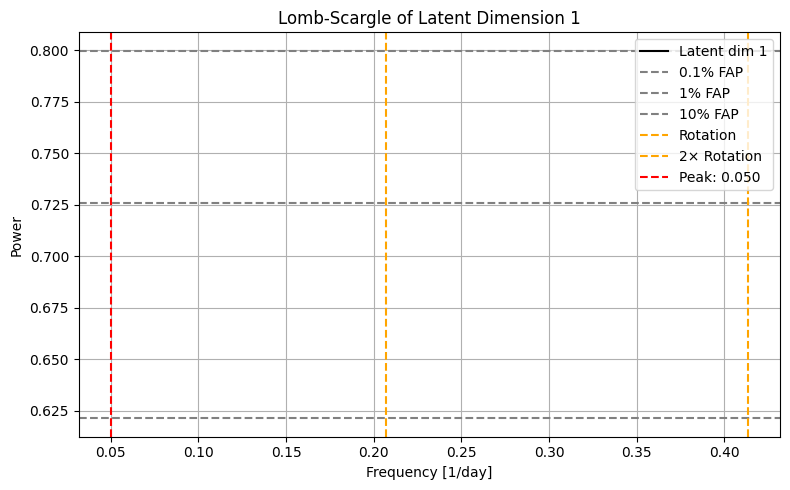

Latent dim 1 — Best period: 20.000 days


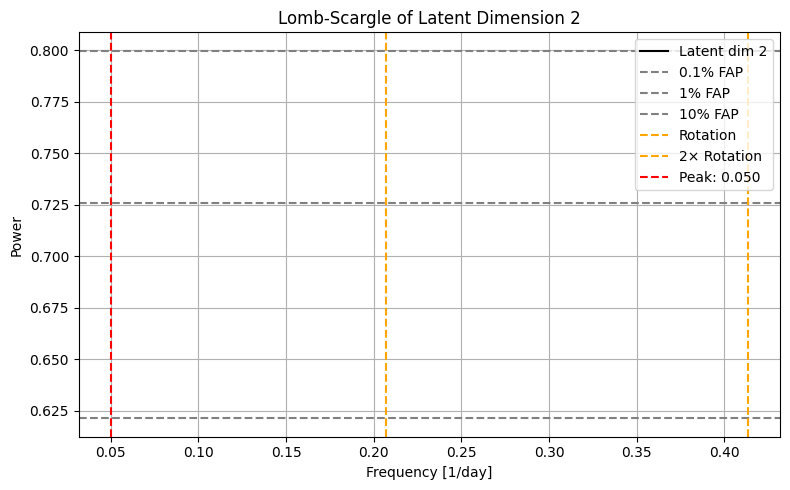

Latent dim 2 — Best period: 20.000 days


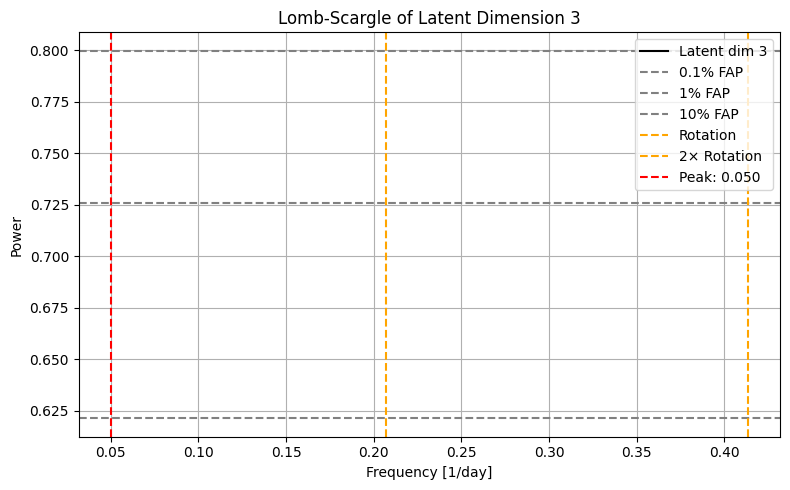

Latent dim 3 — Best period: 20.000 days


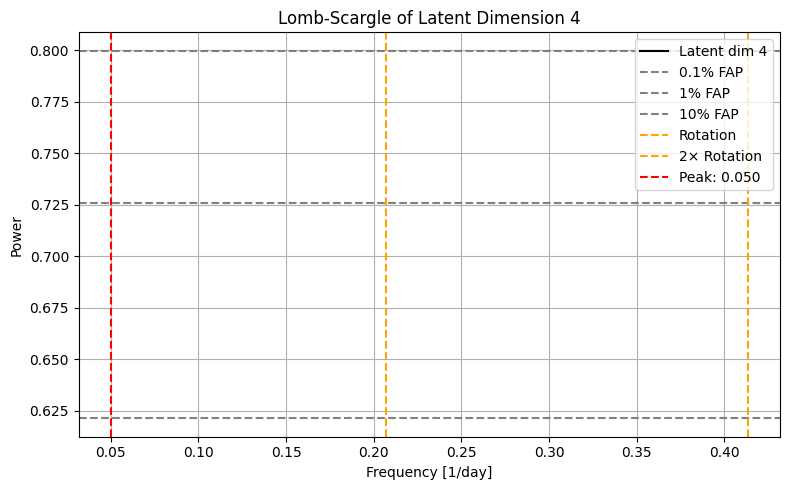

Latent dim 4 — Best period: 20.000 days


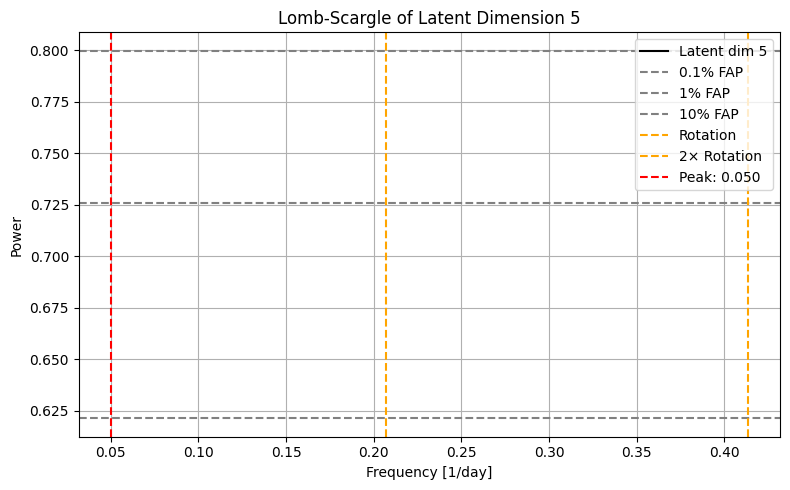

Latent dim 5 — Best period: 20.000 days


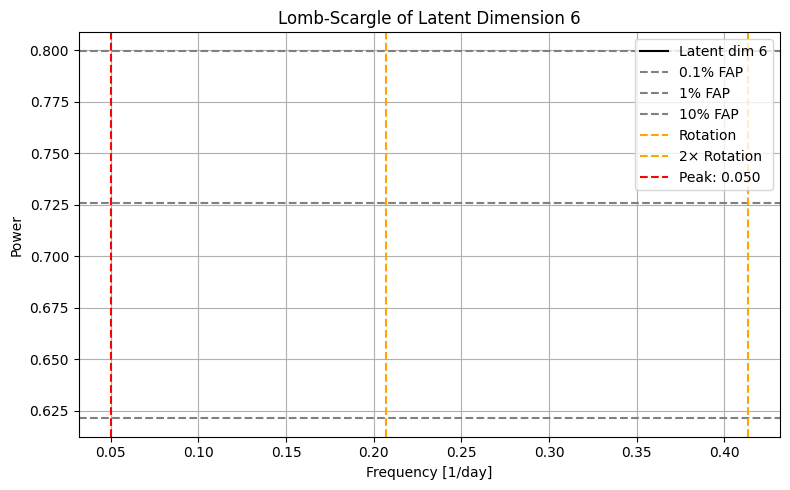

Latent dim 6 — Best period: 20.000 days


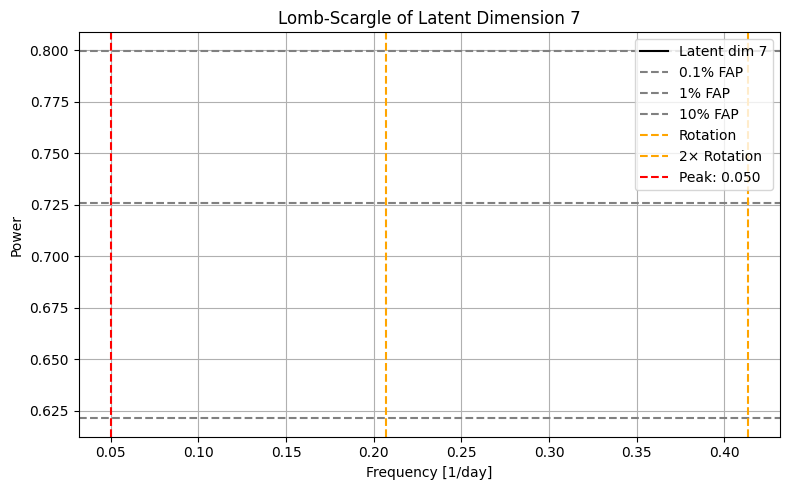

Latent dim 7 — Best period: 20.000 days


In [30]:
for i in range(z_mean.shape[1]):
    y = z_mean[:, i] - np.mean(z_mean[:, i])

    ls = LombScargle(meta_test["BJD"].values, y)
    power = ls.power(frequencies)

    fap_01 = ls.false_alarm_level(0.001)
    fap_1 = ls.false_alarm_level(0.01)
    fap_10 = ls.false_alarm_level(0.1)

    best_freq = frequencies[np.argmax(power)]
    best_period = 1 / best_freq
    second_harmonic = 2 * rotation_freq

    plt.figure(figsize=(8, 5))
    plt.plot(frequencies, power, color="black", label=f"Latent dim {i}")
    plt.axhline(fap_01, color='gray', linestyle='--', label='0.1% FAP')
    plt.axhline(fap_1, color='gray', linestyle='--', label='1% FAP')
    plt.axhline(fap_10, color='gray', linestyle='--', label='10% FAP')
    plt.axvline(rotation_freq, color='orange', linestyle='--', label='Rotation')
    plt.axvline(second_harmonic, color='orange', linestyle='--', label='2× Rotation')
    plt.axvline(best_freq, color='red', linestyle='--', label=f'Peak: {best_freq:.3f}')
    plt.xlabel("Frequency [1/day]")
    plt.ylabel("Power")
    plt.title(f"Lomb-Scargle of Latent Dimension {i}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Latent dim {i} — Best period: {best_period:.3f} days")

### UMAP

gegen RV, FWHM, BIS

/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ice/.pyenv/versions/exoplanets/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


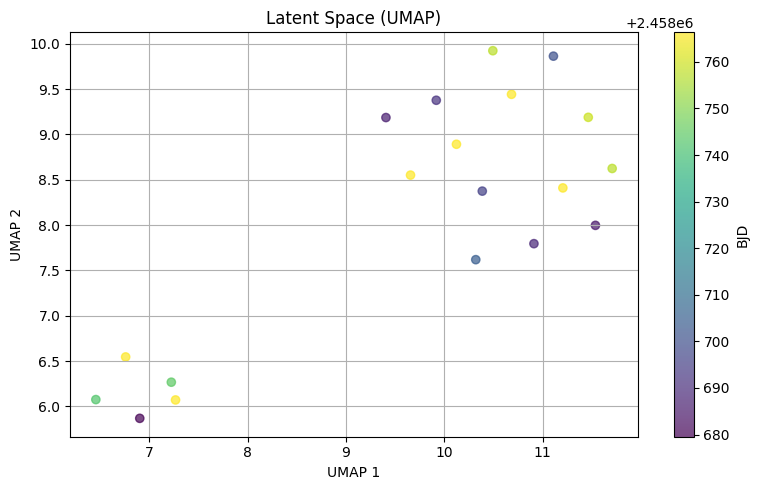

In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42)
latent_umap = reducer.fit_transform(z_mean)

plt.figure(figsize=(8, 5))
plt.scatter(latent_umap[:, 0], latent_umap[:, 1],
            c=meta_test["BJD"], cmap='viridis', alpha=0.7)
plt.colorbar(label="BJD")
plt.title("Latent Space (UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True)
plt.tight_layout()
plt.show()